In [1]:
import os
from pathlib import Path
import torch
from torchvision import transforms
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pyiqa

from network.conv_node import NODE
from misc import *

os.environ["CUDA_VISIBLE_DEVICES"] = '7'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
# CLODE model
model = NODE(device, (3, 400, 600), 32, augment_dim=0, time_dependent=True, adjoint=True)
model.eval()
model.to(device)
model.load_state_dict(torch.load("pth/lowlight.pth", map_location=device, weights_only=True), strict=False)

# - saving trajectory
trajectory = []
ode_func = model.odefunc.forward
def get_trajectory(t, x):
    t_val = t.item() if isinstance(t, torch.Tensor) else float(t)
    t_img = x[:, :3, :, :].detach().cpu()    
    trajectory.append((t_val, t_img))
    return ode_func(t, x)

model.odefunc.forward = get_trajectory

/home/soom/miniconda3/envs/clode/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# LOL Images
IMAGE_PATH = Path("/home/soom/data/LOL/our485")
to_tensor = transforms.ToTensor()

filenames = ['100.png', '200.png', '231.png', '565.png', '781.png']

# Non-reference metrics
niqe_metric = pyiqa.create_metric('niqe', device=device)
brisque_metric = pyiqa.create_metric('brisque', device=device)
pi_metric = pyiqa.create_metric('pi', device=device)
entropy_metric = pyiqa.create_metric('entropy', device=device)

SAVE_PATH = Path('.') / 'interval_predictor' / 'data' / '_unsupervised'

In [3]:
def load_image(filepath):
    img = cv2.imread(str(filepath))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = (np.asarray(img)/255.0)
    img = torch.from_numpy(img).float()
    img = img.permute(2, 0, 1).unsqueeze(0)
    
    return img.to(device)

lq_img = load_image(IMAGE_PATH / 'low' / filenames[3])
gt_img = load_image(IMAGE_PATH / 'high' / filenames[3])
trajectory = []

T = 4
with torch.no_grad():
    integration_time = torch.tensor([0, T]).float().to(device)
    pred = model(lq_img, integration_time, inference=True)['output']
    
    trajectory.sort(key=lambda x: x[0])
    
print(len(trajectory))
t_vals, imgs = zip(*trajectory)
imgs = np.array(imgs)
print(imgs.shape)
print(t_vals)

38
(38, 1, 3, 400, 600)
(0.0, 0.011719371192157269, 0.01535662543028593, 0.023034939542412758, 0.06142650172114372, 0.06825166940689087, 0.07678312063217163, 0.07678312063217163, 0.15113487839698792, 0.18831074237823486, 0.3741901218891144, 0.407235324382782, 0.4485418200492859, 0.4485418200492859, 0.6074838042259216, 0.6869547963142395, 1.084309697151184, 1.154950499534607, 1.2432514429092407, 1.2432514429092407, 1.4485548734664917, 1.5512064695358276, 2.064464569091797, 2.155710458755493, 2.2697677612304688, 2.2697677612304688, 2.4750711917877197, 2.5777230262756348, 3.0909810066223145, 3.1822268962860107, 3.2962839603424072, 3.2962839603424072, 3.5272555351257324, 3.6427412033081055, 4.220169544219971, 4.322823524475098, 4.451140403747559, 4.451140403747559)


T = 4로 돌렸는데 마지막 t value = 4가 아니라 4.451

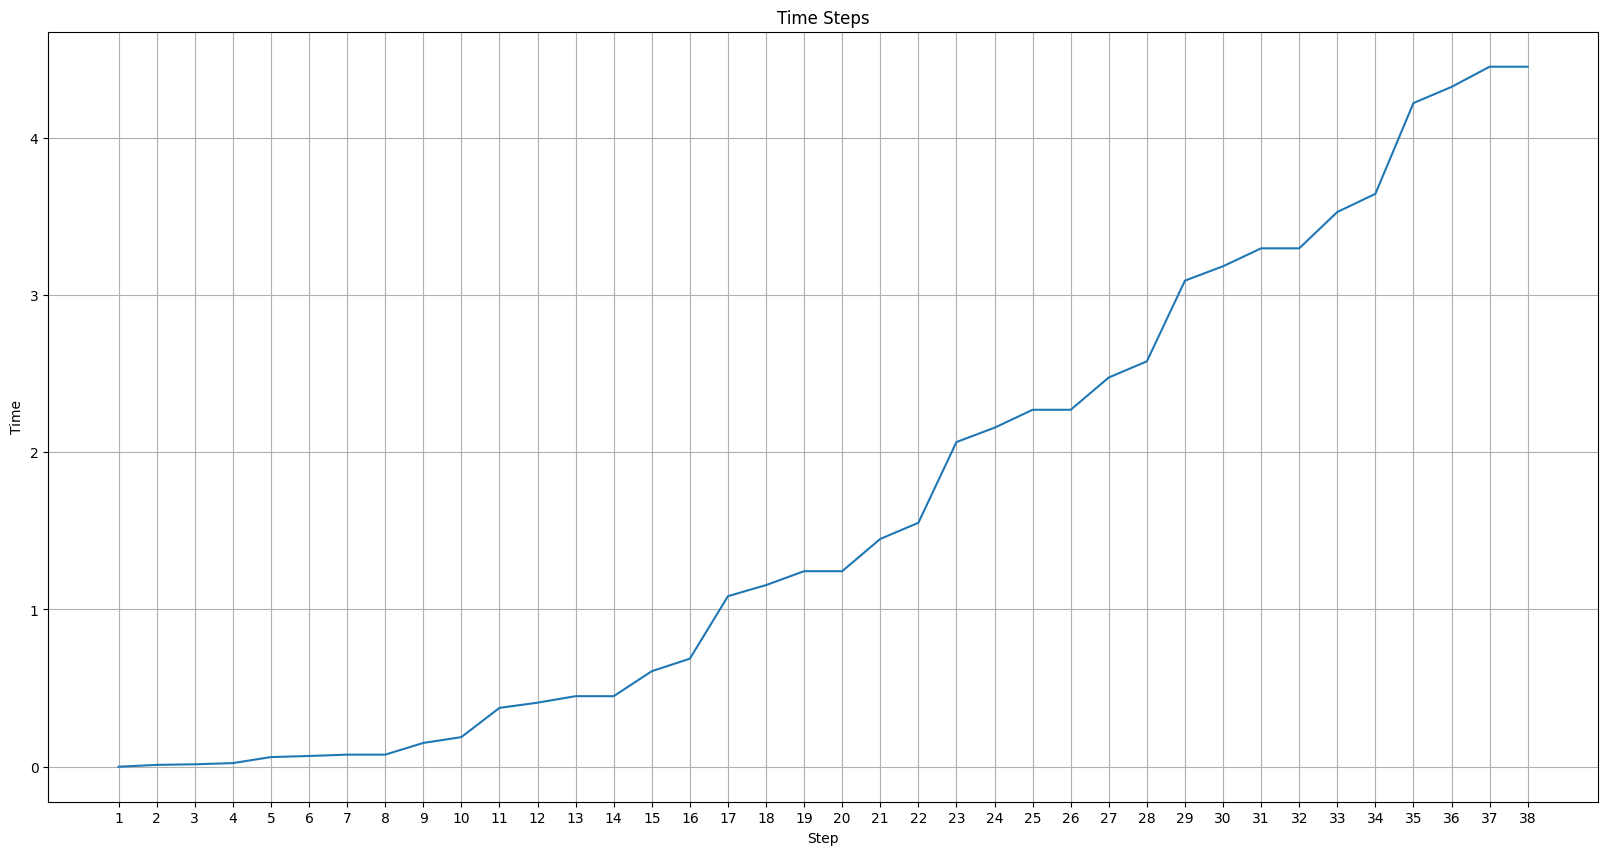

In [4]:
plt.figure(figsize=(20, 10))
x = list(range(1, len(t_vals) + 1))
plt.plot(x, t_vals)
plt.xticks(x)
plt.xlabel('Step')
plt.ylabel('Time')
plt.title('Time Steps')
plt.grid()
plt.show()

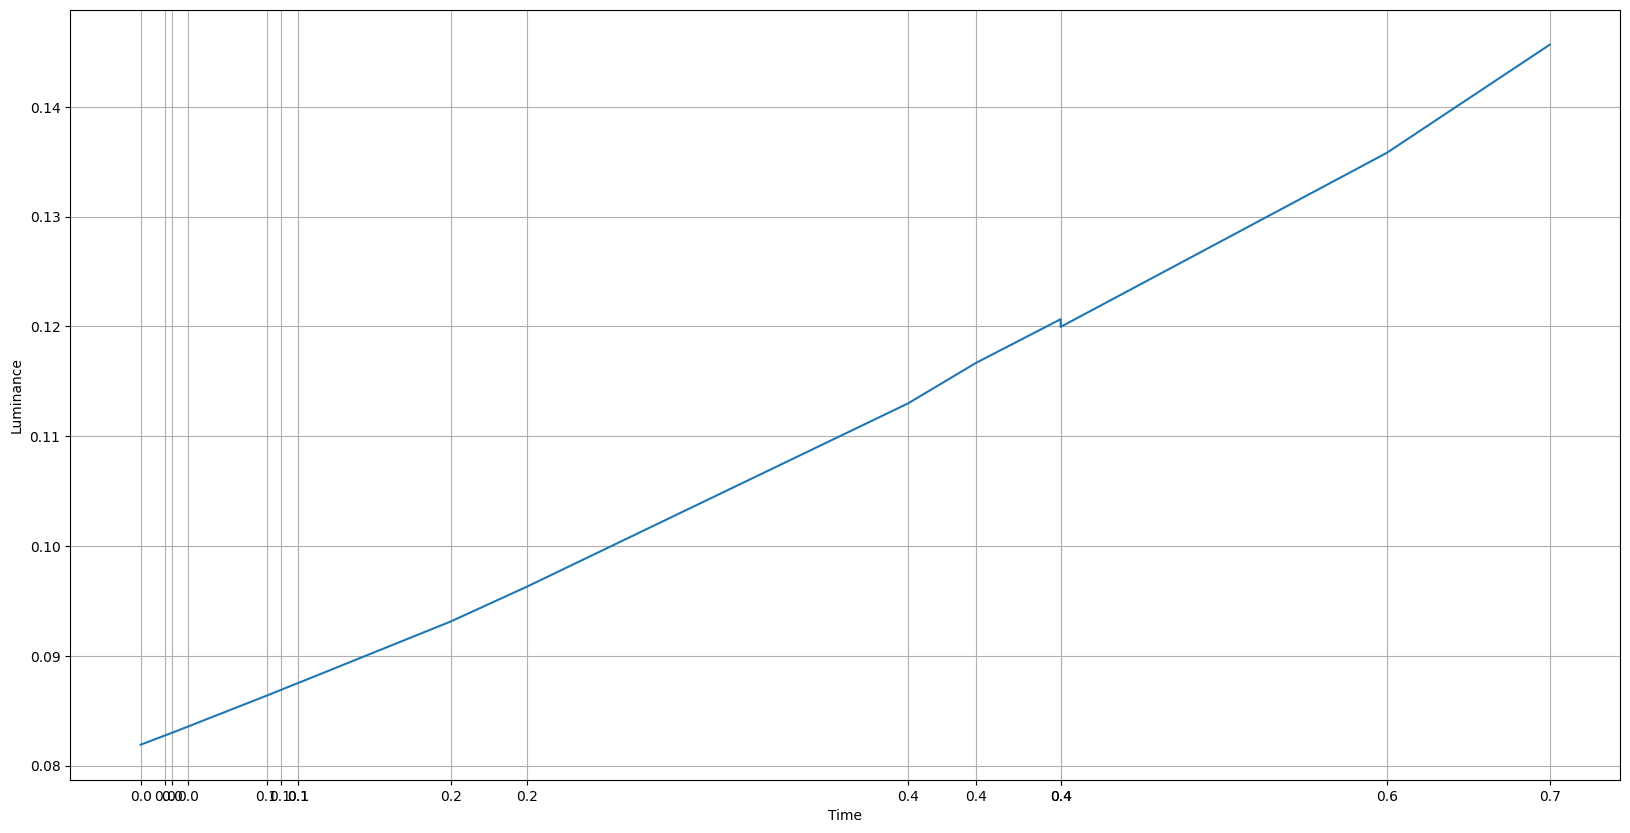

In [5]:
# imgs: (38, 1, 3, 400, 600)
lum = imgs.squeeze(1).max(axis=1)
lum_mean = lum.mean(axis=(1,2))
plt.figure(figsize=(20, 10))
plt.plot(t_vals[:16], lum_mean[:16])
plt.xticks(t_vals[:16], [f"{t:.1f}" for t in t_vals[:16]])
plt.xlabel('Time')
plt.ylabel('Luminance')
plt.grid()
plt.show()

중간 t value를 final state T (T = 0.687)로 놓고 CLODE 다시 돌림
-> trajectory의 마지막 이미지가 t_val = 0.687일 때와 같아야, 우리가 하려는 것이 정당함.

우리가 하려는 것: trajectory 내의 t_val 중에서 PSNR이 가장 높은 t value에 가까운 T를 (어떻게든) 찾아서, 그걸로 CLODE inference를 한다.

In [6]:
t_vals[15]

0.6869547963142395

In [5]:
trajectory = []
with torch.no_grad():
    integration_time = torch.tensor([0, t_vals[15]]).float().to(device)
    pred = model(lq_img, integration_time, inference=True)['output']
print(trajectory[-1][1].shape)

torch.Size([1, 3, 400, 600])


trajectory의 마지막 이미지가 우리가 원하는 T 시점 이미지와 다름
- 이유: trajectory가 T에서 안 멈춤

In [8]:
np.allclose(trajectory[-1][1], imgs[15], rtol=1e-5, atol=1e-8)

False

In [10]:
print(trajectory[-1][0])

1.2432514429092407


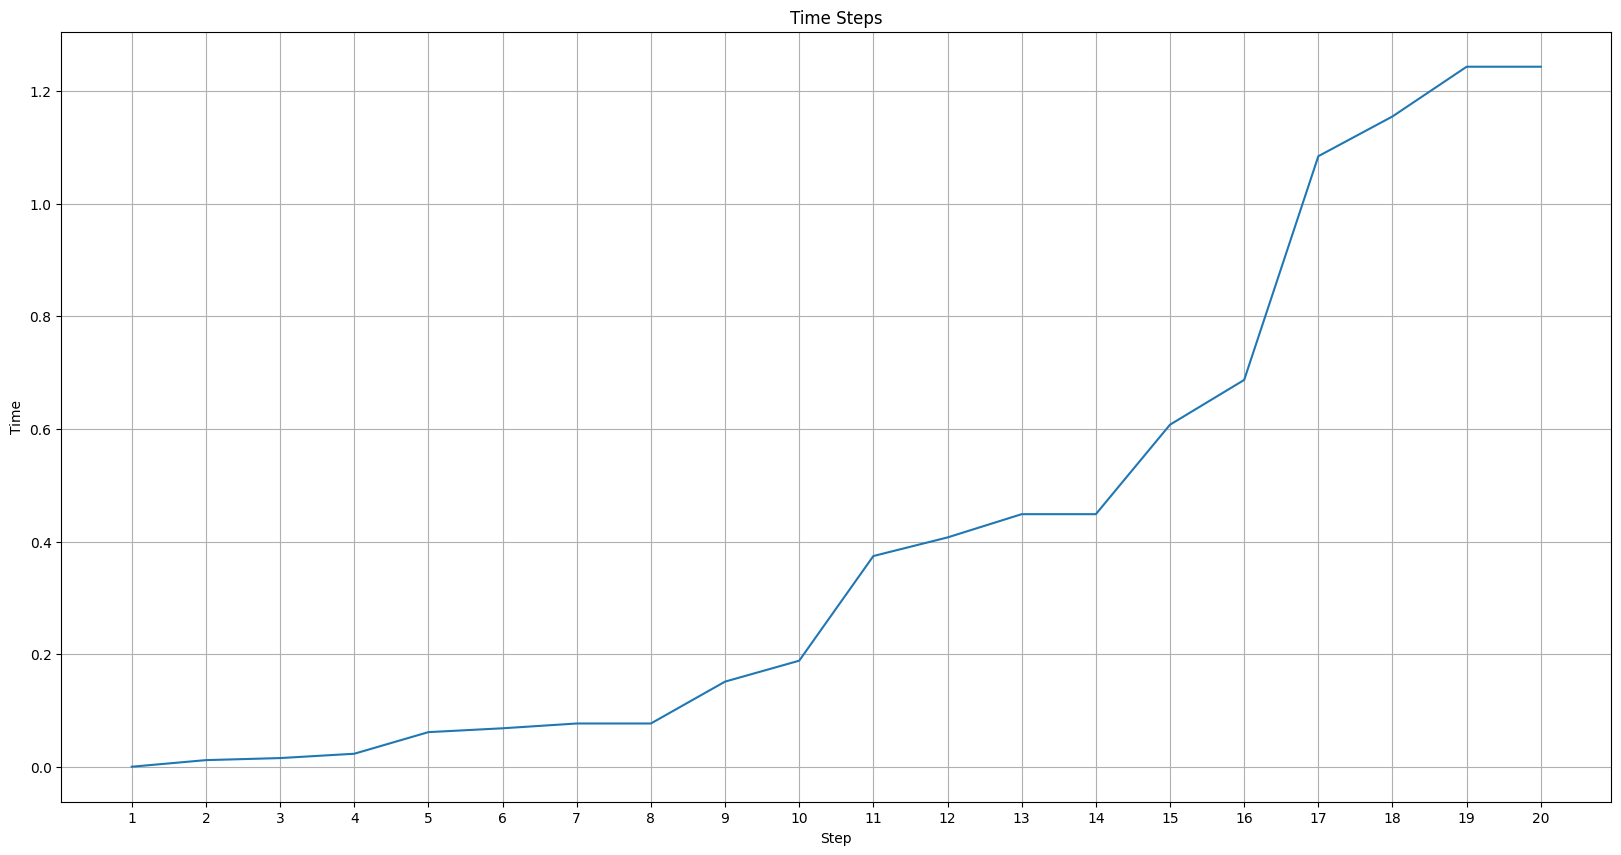

In [6]:
t_vals2, imgs2 = zip(*trajectory)
imgs2 = np.array(imgs2)

plt.figure(figsize=(20, 10))
x = list(range(1, len(t_vals2) + 1))
plt.plot(x, t_vals2)
plt.xticks(x)
plt.xlabel('Step')
plt.ylabel('Time')
plt.title('Time Steps')
plt.grid()
plt.show()

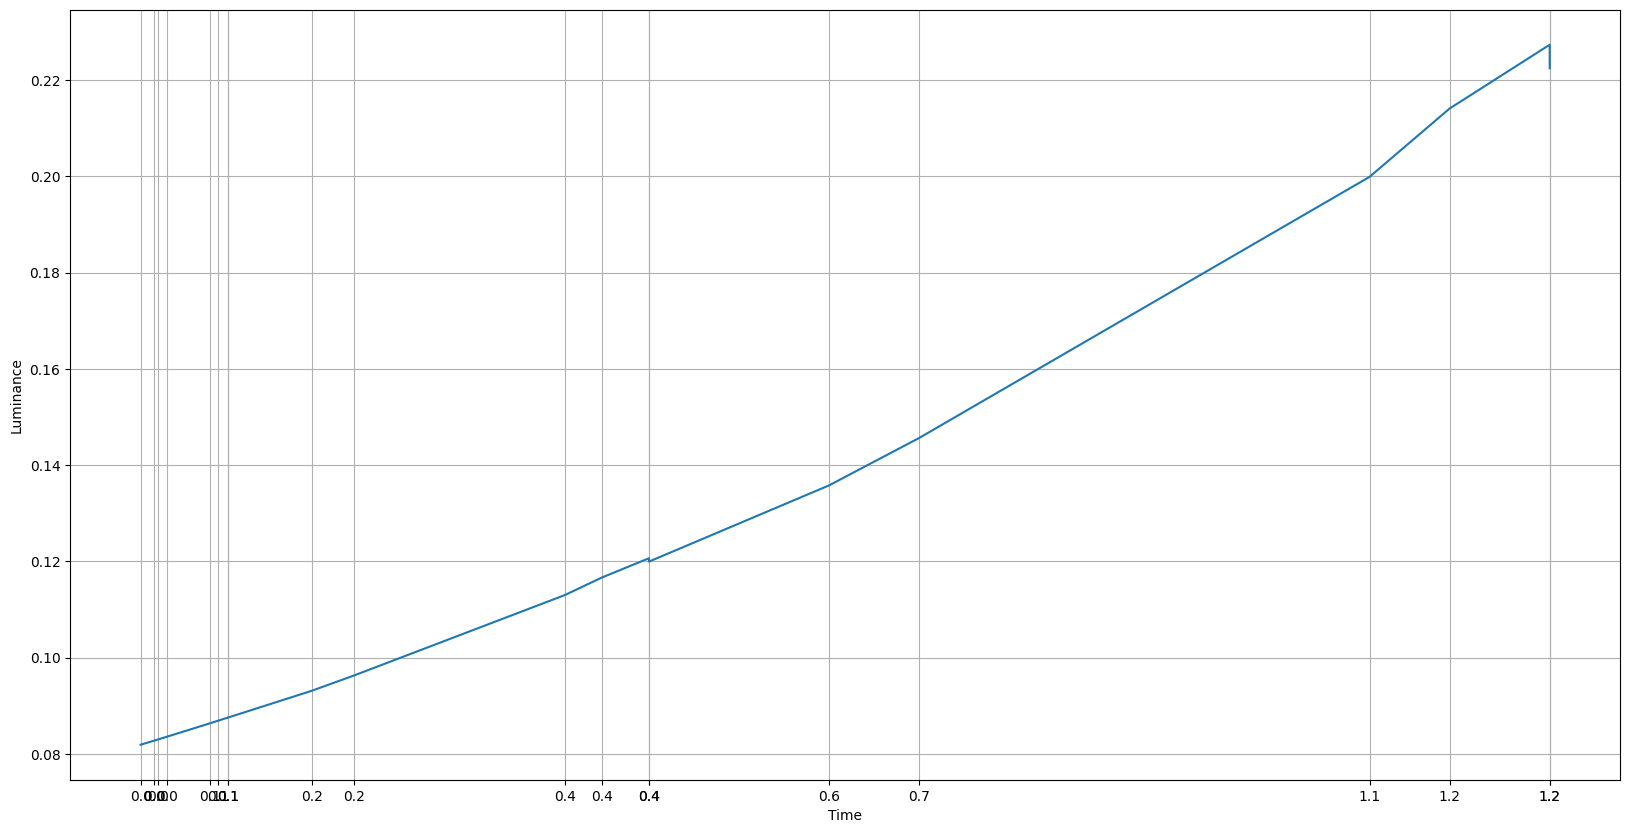

In [10]:
# imgs2: (20, 1, 3, 400, 600)
lum2 = imgs2.squeeze(1).max(axis=1)
lum_mean2 = lum2.mean(axis=(1,2))
plt.figure(figsize=(20, 10))
plt.plot(t_vals2, lum_mean2)
plt.xticks(t_vals2, [f"{t:.1f}" for t in t_vals2])
plt.xlabel('Time')
plt.ylabel('Luminance')
plt.grid()
plt.show()

T를 뭘 넣어주던지 간에 같은 step에서 같은 이미지가 나옴

In [11]:
print(t_vals[15], t_vals2[15])
print(lum_mean[15], lum_mean2[15])

np.allclose(lum_mean[15], lum_mean2[15], rtol=1e-5, atol=1e-8)

0.6869547963142395 0.6869547963142395
0.14565869 0.14565869


True

In [15]:
print(len(t_vals), len(t_vals2))

38 20


In [12]:
for i in range(len(t_vals2)):
    print(np.allclose(lum_mean[i], lum_mean2[i], rtol=1e-5, atol=1e-8))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [18]:
Ts = [3.91, 3.92, 3.93, 3.94, 3.95, 3.96, 3.97, 3.98, 3.99, 4.0]
trajectories = []
with torch.no_grad():
    for T in Ts:
        trajectory = []
        integration_time = torch.tensor([0, T]).float().to(device)
        pred = model(lq_img, integration_time, inference=True)['output']
        trajectory.sort(key=lambda x: x[0])
        trajectories.append(trajectory)
        print(trajectory[-1][0])
        

4.451140403747559
4.451140403747559
4.451140403747559
4.451140403747559
4.451140403747559
4.451140403747559
4.451140403747559
4.451140403747559
4.451140403747559
4.451140403747559


In [7]:
lq_img = load_image(IMAGE_PATH / 'low' / filenames[0])
gt_img = load_image(IMAGE_PATH / 'high' / filenames[0])
trajectory = []
T = 4
with torch.no_grad():
    integration_time = torch.tensor([0, T]).float().to(device)
    pred = model(lq_img, integration_time, inference=True)['output']
trajectory.sort(key=lambda x: x[0])
t_vals, _ = zip(*trajectory)
print(t_vals)

(0.0, 0.01147365476936102, 0.01640155352652073, 0.024602331221103668, 0.06560621410608292, 0.07289579510688782, 0.0820077583193779, 0.0820077583193779, 0.16644945740699768, 0.20867031812667847, 0.4197745621204376, 0.4573042094707489, 0.504216194152832, 0.504216194152832, 0.665313720703125, 0.7458624839782715, 1.1486060619354248, 1.2202050685882568, 1.3097034692764282, 1.3097034692764282, 1.5273034572601318, 1.6361033916473389, 2.180102825164795, 2.2768139839172363, 2.39770245552063, 2.39770245552063, 2.6295835971832275, 2.7455239295959473, 3.325226068496704, 3.428284168243408, 3.5571064949035645, 3.5571064949035645, 3.765976905822754, 3.7903542518615723, 3.8704118728637695, 3.906978130340576, 4.392587184906006, 4.485418319702148, 4.4900970458984375, 4.5937628746032715, 4.601456642150879, 4.601456642150879, 4.723344326019287, 4.723344326019287)


In [9]:
lq_img = load_image(IMAGE_PATH / 'low' / filenames[0])
gt_img = load_image(IMAGE_PATH / 'high' / filenames[0])
Ts = [4.2, 4.21, 4.22, 4.23, 4.24, 4.25]
all_imgs = []
preds = []
with torch.no_grad():
    for T in Ts:
        trajectory = []
        integration_time = torch.tensor([0, T]).float().to(device)
        pred = model(lq_img, integration_time, inference=True)['output']
        
        trajectory.sort(key=lambda x: x[0])
        t_vals, imgs = zip(*trajectory)
        
        preds.append(pred)
        all_imgs.append(imgs)
        print(t_vals)
        
all_imgs = np.array(all_imgs)

print(all_imgs.shape)
print(preds[0].size)

(0.0, 0.01147365476936102, 0.01640155352652073, 0.024602331221103668, 0.06560621410608292, 0.07289579510688782, 0.0820077583193779, 0.0820077583193779, 0.16644945740699768, 0.20867031812667847, 0.4197745621204376, 0.4573042094707489, 0.504216194152832, 0.504216194152832, 0.665313720703125, 0.7458624839782715, 1.1486060619354248, 1.2202050685882568, 1.3097034692764282, 1.3097034692764282, 1.5273034572601318, 1.6361033916473389, 2.180102825164795, 2.2768139839172363, 2.39770245552063, 2.39770245552063, 2.6295835971832275, 2.7455239295959473, 3.325226068496704, 3.428284168243408, 3.5571064949035645, 3.5571064949035645, 3.765976905822754, 3.7903542518615723, 3.8704118728637695, 3.906978130340576, 4.392587184906006, 4.485418319702148, 4.4900970458984375, 4.5937628746032715, 4.601456642150879, 4.601456642150879, 4.723344326019287, 4.723344326019287)
(0.0, 0.01147365476936102, 0.01640155352652073, 0.024602331221103668, 0.06560621410608292, 0.07289579510688782, 0.0820077583193779, 0.0820077583

In [17]:
for pred in preds:
    lum = pred.cpu().numpy().squeeze(0).max(axis=0)
    lum_mean = lum.mean()
    print(f"Luminance mean: {lum_mean:.4f}")
    _psnr = calculate_psnr(pred[0], gt_img[0])
    _ssim = calculate_ssim(pred[0], gt_img[0])
    print(f"PSNR: {_psnr:.2f}, SSIM: {_ssim:.4f}")

Luminance mean: 0.4762
PSNR: 19.07, SSIM: 0.5463
Luminance mean: 0.4776
PSNR: 19.00, SSIM: 0.5448
Luminance mean: 0.4789
PSNR: 18.93, SSIM: 0.5432
Luminance mean: 0.4803
PSNR: 18.85, SSIM: 0.5416
Luminance mean: 0.4816
PSNR: 18.78, SSIM: 0.5401
Luminance mean: 0.4830
PSNR: 18.71, SSIM: 0.5386


In [36]:
for imgs in all_imgs:
    final_step_img = imgs[-1]
    
    # torch.clamp(pred[:, :3, :, :] - self.odefunc.denoise(pred[:, :3, :, :]), 0, 1)

    lum = final_step_img.squeeze(0).max(axis=0)
    lum_mean = lum.mean()
    print(f"Luminance mean: {lum_mean:.4f}")
    
    with torch.no_grad():
        img_t = torch.from_numpy(final_step_img).float().to(device)
        img_t = torch.clamp(img_t - model.odefunc.denoise(img_t), 0, 1)
        img_t = img_t.detach()
    
    _psnr = calculate_psnr(img_t, gt_img[0])
    _ssim = calculate_ssim(img_t, gt_img[0])
    print(f"PSNR: {_psnr:.2f}, SSIM: {_ssim:.4f}")

Luminance mean: 0.5756
PSNR: 15.72, SSIM: 0.4677
Luminance mean: 0.5756
PSNR: 15.72, SSIM: 0.4677
Luminance mean: 0.5756
PSNR: 15.72, SSIM: 0.4677
Luminance mean: 0.5756
PSNR: 15.72, SSIM: 0.4677
Luminance mean: 0.5756
PSNR: 15.72, SSIM: 0.4677
Luminance mean: 0.5756
PSNR: 15.72, SSIM: 0.4677


In [22]:
print(t_vals[-1])

4.723344326019287


In [37]:
lq_img = load_image(IMAGE_PATH / 'low' / filenames[0])
gt_img = load_image(IMAGE_PATH / 'high' / filenames[0])

with torch.no_grad():
    
    trajectory = []
    integration_time = torch.tensor([0, t_vals[-1]]).float().to(device)
    pred = model(lq_img, integration_time, inference=True)['output']
        
    trajectory.sort(key=lambda x: x[0])
    t_vals2, imgs2 = zip(*trajectory)
        
imgs2 = np.array(imgs2)
print(t_vals2)

lum = pred.cpu().numpy().squeeze(0).max(axis=0)
lum_mean = lum.mean()
print(f"Luminance mean: {lum_mean:.4f}")
_psnr = calculate_psnr(pred[0], gt_img[0])
_ssim = calculate_ssim(pred[0], gt_img[0])
print(f"PSNR: {_psnr:.2f}, SSIM: {_ssim:.4f}")

(0.0, 0.01147365476936102, 0.01640155352652073, 0.024602331221103668, 0.06560621410608292, 0.07289579510688782, 0.0820077583193779, 0.0820077583193779, 0.16644945740699768, 0.20867031812667847, 0.4197745621204376, 0.4573042094707489, 0.504216194152832, 0.504216194152832, 0.665313720703125, 0.7458624839782715, 1.1486060619354248, 1.2202050685882568, 1.3097034692764282, 1.3097034692764282, 1.5273034572601318, 1.6361033916473389, 2.180102825164795, 2.2768139839172363, 2.39770245552063, 2.39770245552063, 2.6295835971832275, 2.7455239295959473, 3.325226068496704, 3.428284168243408, 3.5571064949035645, 3.5571064949035645, 3.765976905822754, 3.7903542518615723, 3.8704118728637695, 3.906978130340576, 4.392587184906006, 4.485418319702148, 4.4900970458984375, 4.5937628746032715, 4.601456642150879, 4.601456642150879, 4.723344326019287, 4.723344326019287, 4.8111748695373535, 4.91603422164917, 5.440329074859619, 5.533536911010742, 5.650046348571777, 5.650046348571777)
Luminance mean: 0.5462
PSNR: 1

In [38]:
for imgs in all_imgs:
    final_step_img = imgs[-1]

    lum = final_step_img.squeeze(0).max(axis=0)
    lum_mean = lum.mean()
    print(f"Luminance mean: {lum_mean:.4f}")
    
    img_t = torch.from_numpy(final_step_img).float()
    
    _psnr = calculate_psnr(img_t, gt_img[0])
    _ssim = calculate_ssim(img_t, gt_img[0])
    print(f"PSNR: {_psnr:.2f}, SSIM: {_ssim:.4f}")

Luminance mean: 0.5756
PSNR: 13.78, SSIM: 0.3745
Luminance mean: 0.5756
PSNR: 13.78, SSIM: 0.3745
Luminance mean: 0.5756
PSNR: 13.78, SSIM: 0.3745
Luminance mean: 0.5756
PSNR: 13.78, SSIM: 0.3745
Luminance mean: 0.5756
PSNR: 13.78, SSIM: 0.3745
Luminance mean: 0.5756
PSNR: 13.78, SSIM: 0.3745


In [44]:
T = 4
for filename in filenames:
    lq_img = load_image(IMAGE_PATH / 'low' / filename)
    gt_img = load_image(IMAGE_PATH / 'high' / filename)
    
    with torch.no_grad():
        # T = 4로 놓고 inference
        trajectory = []
        integration_time = torch.tensor([0, T]).float().to(device)
        pred = model(lq_img, integration_time, inference=True)['output']
            
        trajectory.sort(key=lambda x: x[0])
        t_vals, imgs = zip(*trajectory)
        imgs = np.array(imgs)
        
        # ode solver가 마지막으로 계산한 step의 이미지로 luminance, psnr, ssim 계산
        final_step_img = imgs[-1]
        img_t = torch.from_numpy(final_step_img).float().to(device)
        
        lum = final_step_img.squeeze(0).max(axis=0)
        lum_mean = lum.mean()
        print(f"Luminance mean: {lum_mean:.4f}")
        
        img_t = torch.from_numpy(final_step_img).float().to(device)
        img_t = torch.clamp(img_t - model.odefunc.denoise(img_t), 0, 1)
        img_t = img_t.detach()
        
        _psnr = calculate_psnr(img_t, gt_img[0])
        _ssim = calculate_ssim(img_t, gt_img[0])
        _niqe = niqe_metric(img_t).item()
        _brisque = brisque_metric(img_t).item()
        _pi = pi_metric(img_t).item()
        _entropy = entropy_metric(img_t).item()
        print(f"PSNR: {_psnr:.2f}, SSIM: {_ssim:.4f}")
        print(f"NIQE: {_niqe:.4f}, BRISQUE: {_brisque:.4f}, PI: {_pi:.4f}, Entropy: {_entropy:.4f}")
        
        # 위의 final step t value를 T로 두고 inference
        integration_time = torch.tensor([0, t_vals[-1]]).float().to(device)
        pred = model(lq_img, integration_time, inference=True)['output']
            
        # prediction 이미지의 luminance, psnr, ssim 계산: 위와 같을 것으로 예상.
        lum = pred.cpu().numpy().squeeze(0).max(axis=0)
        lum_mean = lum.mean()
        print(f"Luminance mean: {lum_mean:.4f}")
        _psnr = calculate_psnr(pred[0], gt_img[0])
        _ssim = calculate_ssim(pred[0], gt_img[0])
        _niqe = niqe_metric(pred).item()
        _brisque = brisque_metric(pred).item()
        _pi = pi_metric(pred).item()
        _entropy = entropy_metric(pred).item()
        print(f"PSNR: {_psnr:.2f}, SSIM: {_ssim:.4f}")
        print(f"NIQE: {_niqe:.4f}, BRISQUE: {_brisque:.4f}, PI: {_pi:.4f}, Entropy: {_entropy:.4f}")

Luminance mean: 0.5756
PSNR: 15.72, SSIM: 0.4677
NIQE: 5.1005, BRISQUE: 9.7709, PI: 3.5789, Entropy: 7.4474
Luminance mean: 0.5462
PSNR: 15.72, SSIM: 0.4678
NIQE: 5.0938, BRISQUE: 9.7177, PI: 3.5725, Entropy: 7.4473
Luminance mean: 0.4517
PSNR: 18.48, SSIM: 0.4932
NIQE: 5.4857, BRISQUE: 22.4184, PI: 3.7562, Entropy: 7.2018
Luminance mean: 0.4350
PSNR: 18.48, SSIM: 0.4932
NIQE: 5.4843, BRISQUE: 22.4263, PI: 3.7560, Entropy: 7.2018
Luminance mean: 0.5253
PSNR: 16.91, SSIM: 0.4878
NIQE: 4.8390, BRISQUE: 13.3220, PI: 3.4830, Entropy: 7.2400
Luminance mean: 0.4987
PSNR: 16.91, SSIM: 0.4878
NIQE: 4.8395, BRISQUE: 13.3173, PI: 3.4833, Entropy: 7.2400
Luminance mean: 0.8329
PSNR: 7.21, SSIM: 0.3301
NIQE: 3.3135, BRISQUE: 28.8235, PI: 2.7949, Entropy: 6.4783
Luminance mean: 0.8299
PSNR: 7.21, SSIM: 0.3301
NIQE: 3.3091, BRISQUE: 28.8041, PI: 2.7952, Entropy: 6.4783
Luminance mean: 0.8484
PSNR: 8.01, SSIM: 0.4774
NIQE: 4.2672, BRISQUE: 10.0466, PI: 3.0166, Entropy: 6.9211
Luminance mean: 0.8367
P

In [22]:
lq_img = load_image(IMAGE_PATH / 'low' / filenames[1])
gt_img = load_image(IMAGE_PATH / 'high' / filenames[1])
Ts = [1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5]
with torch.no_grad():
    for T in Ts:
        trajectory = []
        integration_time = torch.tensor([0, T]).float().to(device)
        pred = model(lq_img, integration_time, inference=True)['output']
        trajectory.sort(key=lambda x: x[0])
        t_vals, _ = zip(*trajectory)
        print(t_vals)

(0.0, 0.010600575245916843, 0.01881331577897072, 0.028219973668456078, 0.07525326311588287, 0.08361473679542542, 0.0940665677189827, 0.0940665677189827, 0.21294184029102325, 0.27237945795059204, 0.5695676207542419, 0.6224010586738586, 0.6884428262710571, 0.6884428262710571, 0.908287763595581, 1.0182101726531982, 1.5678224563598633, 1.6655312776565552, 1.7876672744750977, 1.7876672744750977)
(0.0, 0.010600575245916843, 0.01881331577897072, 0.028219973668456078, 0.07525326311588287, 0.08361473679542542, 0.0940665677189827, 0.0940665677189827, 0.21294184029102325, 0.27237945795059204, 0.5695676207542419, 0.6224010586738586, 0.6884428262710571, 0.6884428262710571, 0.908287763595581, 1.0182101726531982, 1.5678224563598633, 1.6655312776565552, 1.7876672744750977, 1.7876672744750977)
(0.0, 0.010600575245916843, 0.01881331577897072, 0.028219973668456078, 0.07525326311588287, 0.08361473679542542, 0.0940665677189827, 0.0940665677189827, 0.21294184029102325, 0.27237945795059204, 0.569567620754241